# 캠페인 효과 검증: 매칭 + Difference-in-Differences

목표는 캠페인을 받은 고객의 매출 변화가 캠페인을 받지 않은 비슷한 고객보다 컸는지 확인하는 것입니다.

- 처리군: 해당 캠페인에 배정된 고객
- 비교군: 해당 캠페인 및 같은 기간의 다른 캠페인에 배정되지 않은 고객
- 매칭 기준: 캠페인 시작 전 고객별 매출과 장바구니 수
- 효과: `(처리군 캠페인 중 - 처리군 캠페인 전) - (비교군 캠페인 중 - 비교군 캠페인 전)`

캠페인 24번은 거래 관측 종료일(DAY 711)보다 늦게 끝나므로 제외합니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "data" / "processed"
TRANSACTION_PATH = PROJECT_DIR / "transaction_data.csv"
CAMPAIGN_DESC_PATH = PROJECT_DIR / "campaign_desc.csv"
CAMPAIGN_TABLE_PATH = PROJECT_DIR / "campaign_table.csv"
REDEMPTION_PATH = PROJECT_DIR / "coupon_redempt.csv"
DATASET_END_DAY = 711

## 1. 데이터 불러오기 및 분석 대상 확정

In [2]:
tx = pd.read_csv(
    TRANSACTION_PATH,
    usecols=["household_key","BASKET_ID","DAY","SALES_VALUE"],
    dtype={"household_key":"int32","BASKET_ID":"int64","DAY":"int16","SALES_VALUE":"float32"},
)
campaign_desc = pd.read_csv(CAMPAIGN_DESC_PATH)
campaign_table = pd.read_csv(CAMPAIGN_TABLE_PATH)
redemptions = pd.read_csv(REDEMPTION_PATH)
all_households = np.sort(tx["household_key"].unique())
valid_campaigns = campaign_desc.loc[campaign_desc["END_DAY"] <= DATASET_END_DAY].copy()
print(f"거래 고객: {len(all_households):,}명")
print(f"전체 캠페인: {len(campaign_desc)}개 / 완전 관측 캠페인: {len(valid_campaigns)}개")
display(campaign_desc.loc[campaign_desc["END_DAY"] > DATASET_END_DAY])

거래 고객: 2,500명
전체 캠페인: 30개 / 완전 관측 캠페인: 29개


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719


## 2. 고객별 전·중 성과와 비교군 매칭 함수

각 캠페인의 진행 일수와 동일한 길이로 직전 기간을 설정합니다. 비교군 오염을 줄이기 위해 분석 기간과 겹치는 다른 캠페인에 배정된 고객도 비교군에서 제외합니다.

In [3]:
def customer_period_metrics(start_day, end_day):
    duration = end_day - start_day + 1
    pre_start, pre_end = start_day - duration, start_day - 1
    window = tx.loc[tx["DAY"].between(pre_start, end_day)].copy()
    window["period"] = np.where(window["DAY"] < start_day, "pre", "during")
    metrics = window.groupby(["household_key","period"]).agg(
        revenue=("SALES_VALUE","sum"), baskets=("BASKET_ID","nunique")
    ).unstack(fill_value=0)
    metrics.columns = [f"{metric}_{period}" for metric, period in metrics.columns]
    metrics = metrics.reindex(all_households, fill_value=0).reset_index()
    for col in ["revenue_pre","revenue_during","baskets_pre","baskets_during"]:
        if col not in metrics: metrics[col] = 0
    metrics["duration_days"] = duration
    metrics["revenue_pre_daily"] = metrics["revenue_pre"] / duration
    metrics["revenue_during_daily"] = metrics["revenue_during"] / duration
    metrics["baskets_pre_daily"] = metrics["baskets_pre"] / duration
    metrics["baskets_during_daily"] = metrics["baskets_during"] / duration
    return metrics, pre_start, pre_end

def nearest_controls(treated, controls):
    feature_cols = ["revenue_pre_daily","baskets_pre_daily"]
    combined = pd.concat([treated[feature_cols], controls[feature_cols]])
    x = np.log1p(combined.to_numpy(float))
    mean, std = x.mean(axis=0), x.std(axis=0)
    std[std == 0] = 1
    t = (np.log1p(treated[feature_cols].to_numpy(float)) - mean) / std
    c = (np.log1p(controls[feature_cols].to_numpy(float)) - mean) / std
    distances = ((t[:, None, :] - c[None, :, :]) ** 2).sum(axis=2)
    return controls.iloc[distances.argmin(axis=1)].reset_index(drop=True)

def standardized_mean_difference(a, b):
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return 0 if pooled == 0 else (a.mean() - b.mean()) / pooled

## 3. 캠페인별 효과 계산

`incremental_revenue_daily`가 양수면 캠페인 대상 고객의 매출 증가가 비교군보다 컸다는 뜻입니다. 신뢰구간에 0이 포함되면 효과의 방향이 불확실합니다.

In [4]:
campaign_results, matched_rows = [], []
for row in valid_campaigns.sort_values("CAMPAIGN").itertuples(index=False):
    campaign_id, campaign_type = int(row.CAMPAIGN), row.DESCRIPTION
    start_day, end_day = int(row.START_DAY), int(row.END_DAY)
    metrics, pre_start, pre_end = customer_period_metrics(start_day, end_day)
    treated_ids = set(campaign_table.loc[campaign_table["CAMPAIGN"] == campaign_id, "household_key"])

    overlapping_ids = set()
    overlaps = campaign_desc.loc[(campaign_desc["START_DAY"] <= end_day) & (campaign_desc["END_DAY"] >= pre_start)]
    for overlap_id in overlaps["CAMPAIGN"]:
        overlapping_ids.update(campaign_table.loc[campaign_table["CAMPAIGN"] == overlap_id, "household_key"])

    treated = metrics.loc[metrics["household_key"].isin(treated_ids)].reset_index(drop=True)
    controls = metrics.loc[~metrics["household_key"].isin(overlapping_ids)].reset_index(drop=True)
    if treated.empty or controls.empty: continue
    matched = nearest_controls(treated, controls)

    treated_change_revenue = treated["revenue_during_daily"].to_numpy() - treated["revenue_pre_daily"].to_numpy()
    control_change_revenue = matched["revenue_during_daily"].to_numpy() - matched["revenue_pre_daily"].to_numpy()
    treated_change_baskets = treated["baskets_during_daily"].to_numpy() - treated["baskets_pre_daily"].to_numpy()
    control_change_baskets = matched["baskets_during_daily"].to_numpy() - matched["baskets_pre_daily"].to_numpy()
    revenue_effect = treated_change_revenue - control_change_revenue
    basket_effect = treated_change_baskets - control_change_baskets
    se = revenue_effect.std(ddof=1) / np.sqrt(len(revenue_effect)) if len(revenue_effect) > 1 else np.nan
    redemption_households = redemptions.loc[redemptions["CAMPAIGN"] == campaign_id, "household_key"].nunique()

    campaign_results.append({
        "campaign": campaign_id, "campaign_type": campaign_type, "start_day": start_day, "end_day": end_day,
        "duration_days": end_day-start_day+1, "treated_customers": len(treated),
        "unique_matched_controls": matched["household_key"].nunique(),
        "control_reuse_ratio": matched["household_key"].nunique() / len(treated),
        "pre_revenue_balance_smd": standardized_mean_difference(treated["revenue_pre_daily"], matched["revenue_pre_daily"]),
        "treated_pre_revenue_daily": treated["revenue_pre_daily"].mean(),
        "treated_during_revenue_daily": treated["revenue_during_daily"].mean(),
        "control_pre_revenue_daily": matched["revenue_pre_daily"].mean(),
        "control_during_revenue_daily": matched["revenue_during_daily"].mean(),
        "incremental_revenue_daily": revenue_effect.mean(),
        "incremental_revenue_ci_low": revenue_effect.mean() - 1.96*se,
        "incremental_revenue_ci_high": revenue_effect.mean() + 1.96*se,
        "incremental_baskets_daily": basket_effect.mean(),
        "redemption_households": redemption_households,
        "redemption_rate": redemption_households / len(treated),
    })
    pair = pd.DataFrame({
        "campaign": campaign_id, "campaign_type": campaign_type,
        "treated_household": treated["household_key"].to_numpy(),
        "control_household": matched["household_key"].to_numpy(),
        "revenue_effect_daily": revenue_effect, "basket_effect_daily": basket_effect,
    })
    matched_rows.append(pair)

campaign_effectiveness = pd.DataFrame(campaign_results).sort_values("campaign")
matched_customer_effects = pd.concat(matched_rows, ignore_index=True)
display(campaign_effectiveness.head())

,campaign,campaign_type,start_day,end_day,duration_days,treated_customers,unique_matched_controls,control_reuse_ratio,pre_revenue_balance_smd,treated_pre_revenue_daily,treated_during_revenue_daily,control_pre_revenue_daily,control_during_revenue_daily,incremental_revenue_daily,incremental_revenue_ci_low,incremental_revenue_ci_high,incremental_baskets_daily,redemption_households,redemption_rate
0,1,TypeB,346,383,38,13,13,1.000000,0.019435,6.525445,7.597651,6.453907,5.794149,1.731964,-0.341802,3.805729,0.070850,1,0.076923
1,2,TypeB,351,383,33,48,47,0.979167,0.082633,7.303282,7.320215,6.835909,6.592298,0.260543,-1.130770,1.651856,0.001894,2,0.041667
2,3,TypeC,356,412,57,12,12,1.000000,0.126617,12.802938,12.510761,11.756111,13.863494,-2.399561,-5.634246,0.835125,-0.083333,2,0.166667
3,4,TypeB,372,404,33,81,71,0.876543,0.045502,9.505073,9.922076,9.211055,7.870142,1.757916,0.463633,3.052199,0.025440,6,0.074074
4,5,TypeB,377,411,35,166,127,0.765060,0.032454,12.219719,12.381068,11.929071,10.652215,1.438205,0.292771,2.583638,0.026850,8,0.048193


## 4. 매칭 품질과 캠페인별 결과 확인

`pre_revenue_balance_smd`의 절댓값이 0.1 이하이면 사전 매출 균형이 양호한 편입니다. 표본이 매우 작은 캠페인은 신뢰구간이 넓으므로 확정적 결론을 피합니다.

In [5]:
quality_summary = pd.Series({
    "campaigns": len(campaign_effectiveness),
    "good_balance_campaigns": int((campaign_effectiveness["pre_revenue_balance_smd"].abs() <= .1).sum()),
    "positive_effect_campaigns": int((campaign_effectiveness["incremental_revenue_daily"] > 0).sum()),
    "ci_excludes_zero_positive": int((campaign_effectiveness["incremental_revenue_ci_low"] > 0).sum()),
})
display(quality_summary.to_frame("value"))
display(campaign_effectiveness.sort_values("incremental_revenue_daily", ascending=False).head(10))

,value
campaigns,29
good_balance_campaigns,22
positive_effect_campaigns,26
ci_excludes_zero_positive,18


,campaign,campaign_type,start_day,end_day,duration_days,treated_customers,unique_matched_controls,control_reuse_ratio,pre_revenue_balance_smd,treated_pre_revenue_daily,treated_during_revenue_daily,control_pre_revenue_daily,control_during_revenue_daily,incremental_revenue_daily,incremental_revenue_ci_low,incremental_revenue_ci_high,incremental_baskets_daily,redemption_households,redemption_rate
20,21,TypeB,624,656,33,65,47,0.723077,0.135610,12.785310,13.960709,11.712490,6.971693,5.916196,3.565791,8.266601,0.065734,4,0.061538
18,19,TypeB,603,635,33,130,89,0.684615,0.092240,10.433805,11.111685,9.755548,6.515037,3.918391,2.891995,4.944788,0.043357,15,0.115385
22,23,TypeB,646,684,39,183,91,0.497268,0.121330,14.148350,13.716665,12.983180,8.928103,3.623394,2.665598,4.581189,0.063192,23,0.125683
21,22,TypeB,624,656,33,276,140,0.507246,0.040491,11.526906,11.833167,11.223500,8.266886,3.262874,2.301724,4.224025,0.067962,17,0.061594
19,20,TypeC,615,685,71,244,98,0.401639,0.014276,11.460947,12.452436,11.319592,9.960117,2.350964,1.585424,3.116504,0.005426,20,0.081967
23,25,TypeB,659,691,33,187,87,0.465241,0.134319,14.725277,13.844496,13.240482,10.020831,2.338872,1.185922,3.491823,0.043753,24,0.128342
26,28,TypeB,259,320,62,17,17,1.000000,-0.017704,10.366063,10.750313,10.444886,8.687136,2.142002,-1.535853,5.819857,-0.000949,1,0.058824
5,6,TypeC,393,425,33,65,47,0.723077,0.082890,14.804774,14.729725,14.112616,12.166750,1.870816,-0.055840,3.797471,0.030303,1,0.015385
3,4,TypeB,372,404,33,81,71,0.876543,0.045502,9.505073,9.922076,9.211055,7.870142,1.757916,0.463633,3.052199,0.025440,6,0.074074
0,1,TypeB,346,383,38,13,13,1.000000,0.019435,6.525445,7.597651,6.453907,5.794149,1.731964,-0.341802,3.805729,0.070850,1,0.076923


## 5. 캠페인 유형별 요약

캠페인 수가 다르므로 단순 평균과 함께 중앙값, 양의 효과를 보인 캠페인 비율을 확인합니다. 이는 유형 간 인과적 우열의 확정이 아니라 다음 캠페인 설계를 위한 탐색 결과입니다.

In [6]:
campaign_type_summary = campaign_effectiveness.groupby("campaign_type").agg(
    campaigns=("campaign","nunique"), total_treated=("treated_customers","sum"),
    mean_incremental_revenue_daily=("incremental_revenue_daily","mean"),
    median_incremental_revenue_daily=("incremental_revenue_daily","median"),
    mean_incremental_baskets_daily=("incremental_baskets_daily","mean"),
    mean_redemption_rate=("redemption_rate","mean"),
    positive_campaign_rate=("incremental_revenue_daily", lambda x: (x > 0).mean()),
).reset_index()
display(campaign_type_summary)

,campaign_type,campaigns,total_treated,mean_incremental_revenue_daily,median_incremental_revenue_daily,mean_incremental_baskets_daily,mean_redemption_rate,positive_campaign_rate
0,TypeA,5,3979,0.532264,0.614201,0.013393,0.142161,1.0
1,TypeB,18,2555,2.017835,1.629810,0.037288,0.078083,1.0
2,TypeC,6,574,0.077957,0.419149,-0.021009,0.090893,0.5


/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_34247/2612355817.py:6: UserWarning: Glyph 52896 (\N{HANGUL SYLLABLE KAEM}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_34247/2612355817.py:6: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_34247/2612355817.py:6: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_34247/2612355817.py:6: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_34247/2612355817.py:6: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x69

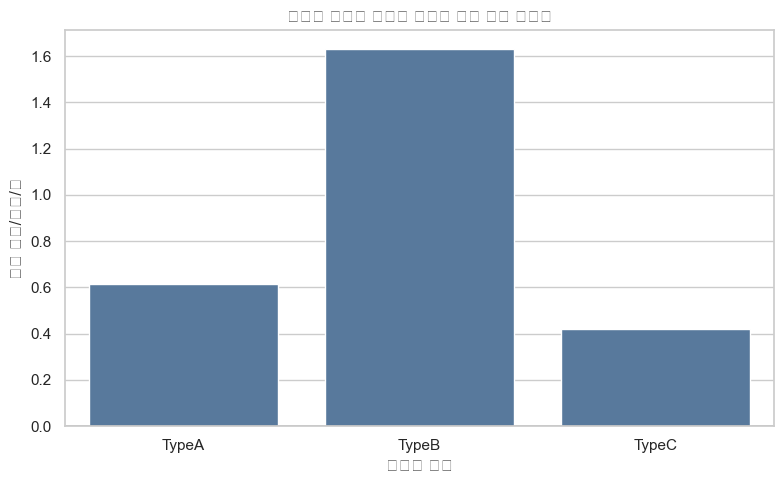

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=campaign_type_summary, x="campaign_type", y="median_incremental_revenue_daily", color="#4C78A8")
plt.axhline(0, color="black", linewidth=1)
plt.title("캠페인 유형별 고객당 일평균 증분 매출 중앙값")
plt.xlabel("캠페인 유형"); plt.ylabel("증분 매출/고객/일")
plt.tight_layout(); plt.show()

## 6. 해석 원칙

- 효과가 양수: 처리군의 전후 증가폭이 매칭 비교군보다 큼
- 95% 근사 신뢰구간에 0 포함: 효과 방향을 확정하기 어려움
- 쿠폰 사용률이 높아도 증분 매출이 없다면 원래 살 고객에게 할인했을 가능성이 있음
- `control_reuse_ratio`가 낮으면 같은 비교 고객이 여러 번 재사용된 것이므로 불확실성을 더 보수적으로 해석해야 함
- 이 데이터는 무작위 실험이 아니므로 매칭 후에도 관측되지 않은 차이가 남을 수 있음
- 현재 세그먼트는 DAY 655 기준이라 과거 캠페인 효과에 직접 사용하지 않음. 세그먼트별 과거 효과를 보려면 각 캠페인 시작일 기준으로 세그먼트를 다시 만들어야 함

In [8]:
campaign_effectiveness.to_csv(OUTPUT_DIR / "campaign_effectiveness.csv", index=False, encoding="utf-8-sig")
campaign_type_summary.to_csv(OUTPUT_DIR / "campaign_type_summary.csv", index=False, encoding="utf-8-sig")
matched_customer_effects.to_csv(OUTPUT_DIR / "matched_customer_campaign_effects.csv", index=False, encoding="utf-8-sig")
print("결과 3개 저장 완료")

결과 3개 저장 완료
